![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [3]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [4]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [5]:
# Celda 1

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Definición de parámetros y criterios de parada
max_depth= None
num_pct= 10
max_features= None
min_gain=0.001
j=1


In [6]:
# 1. Definición de la función Sum Squared Errors SSE (al ser un árbol de regresión) para calcular la ganancia de una variable predictora dado el punto de corte

def sse(y):
    if y.shape[0] == 0:
        return 0
    return np.sum((y - y.mean()) ** 2)


In [7]:
# 2. Se define la función que busca el mejor split

def best_split(X, y, num_pct, max_features):
    best_gain = -np.inf
    best_col = None
    best_threshold = None
    
    # Si max_features está definido, muestrear columnas aleatoriamente
    cols = np.arange(X.shape[1])
    if max_features is not None:
        cols = np.random.choice(cols, max_features, replace=False)
    
    sse_padre = sse(y)
    
    for j in cols:
        # Candidatos a umbral: num_pct percentiles de la variable j
        percentiles = np.arange(0, 100, 100.0 / num_pct)
        umbrales = np.unique(np.percentile(X.iloc[:, j], percentiles))
        
        for v in umbrales:
            mask = X.iloc[:, j] < v
            y_l = y[mask]
            y_r = y[~mask]
            
            ganancia = sse_padre - sse(y_l) - sse(y_r)
            
            if ganancia > best_gain:
                best_gain = ganancia
                best_col = j
                best_threshold = v
    
    return best_col, best_threshold, best_gain

In [8]:
# 3. Definición de una función recursiva que construye el árbol: parte el nodo, genera dos hijos y se llama a sí misma hasta que se cumpla un criterio de parada

def build_tree(X, y, num_pct, max_features, min_gain, max_depth, depth=0):
    # Criterio de parada 1: nodo puro o muy pequeño
    if y.shape[0] <= 1:
        return y.mean()
    
    # Criterio de parada 2: profundidad máxima alcanzada
    if max_depth is not None and depth >= max_depth:
        return y.mean()
    
    col, threshold, gain = best_split(X, y, num_pct, max_features)
    
    # Criterio de parada 3: la ganancia es demasiado pequeña
    if gain < min_gain or threshold is None:
        return y.mean()
    
    # Split
    mask = X.iloc[:, col] < threshold
    
    # Construcción recursiva
    arbol = {
        'col': col,
        'threshold': threshold,
        'left': build_tree(X[mask], y[mask], num_pct, max_features, 
                           min_gain, max_depth, depth + 1),
        'right': build_tree(X[~mask], y[~mask], num_pct, max_features, 
                            min_gain, max_depth, depth + 1)
    }
    return arbol

In [9]:
# 4. Realizar predicciones

def predict_row(arbol, row):
    # Si es un número, es una hoja → devolver la predicción
    if not isinstance(arbol, dict):
        return arbol
    
    # Si la observación cumple la condición, va a la izquierda
    if row.iloc[arbol['col']] < arbol['threshold']:
        return predict_row(arbol['left'], row)
    else:
        return predict_row(arbol['right'], row)

def predict(arbol, X):
    return X.apply(lambda row: predict_row(arbol, row), axis=1)

In [10]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

arbol = build_tree(X_train, y_train, num_pct, max_features, min_gain, max_depth)

y_pred = predict(arbol, X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"El RMSE calculado es de: {rmse:.2f}")
print(f"El MAE calculado es de:  {mae:.2f}")

El RMSE calculado es de: 2120.60
El MAE calculado es de:  1577.95


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [11]:
# Celda 2

n_estimators = 10

# Paso 1: entrenar B árboles sobre muestras bootstrap
arboles = []

for i in range(n_estimators):
    # Bootstrap: muestra con reemplazo del mismo tamaño que X_train
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[indices].reset_index(drop=True)
    y_boot = y_train.iloc[indices].reset_index(drop=True)
    
    # Entrenar árbol sobre esa muestra
    arbol_i = build_tree(X_boot, y_boot, num_pct, max_features, min_gain, max_depth)
    arboles.append(arbol_i)
    print(f"Árbol {i+1}/10 entrenado")

# Paso 2: predecir con cada árbol y promediar
predicciones = np.array([predict(arbol_i, X_test).values for arbol_i in arboles])
y_pred_bagging = predicciones.mean(axis=0)

# Paso 3: evaluar
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae_bag = mean_absolute_error(y_test, y_pred_bagging)

print(f"\nEl valor de RMSE para Bagging manual fue de: {rmse_bag:.2f}")
print(f"El valor de MAE para Bagging manual fue de::  {mae_bag:.2f}")
print(f"="*80)
print(f"Comparación:")
print(f"Árbol simple del punto 1 -RMSE: {rmse:.2f} y MAE: {mae:.2f}")
print(f"Bagging ({n_estimators}) - RMSE: {rmse_bag:.2f} y MAE: {mae_bag:.2f}")

Árbol 1/10 entrenado
Árbol 2/10 entrenado
Árbol 3/10 entrenado
Árbol 4/10 entrenado
Árbol 5/10 entrenado
Árbol 6/10 entrenado
Árbol 7/10 entrenado
Árbol 8/10 entrenado
Árbol 9/10 entrenado
Árbol 10/10 entrenado

El valor de RMSE para Bagging manual fue de: 1752.70
El valor de MAE para Bagging manual fue de::  1306.59
Comparación:
Árbol simple del punto 1 -RMSE: 2120.60 y MAE: 1577.95
Bagging (10) - RMSE: 1752.70 y MAE: 1306.59


**Conclusiones Punto 2:**

Conforme a la teoría, los resultados para el Bagging fueron superiores a los del Árbol Simple del primer punto. El Bagging redujo el error promedio (`MAE`) y también el RMSE, porque según la metodología del bagging, al entrenar varios árboles, los errores se van cancelando porque cada árbol fue entrenado en una muestra bootstap distinta, lo que hace que sus errores sean en parte independientes entre sí, reduciendo la varianza general del modelo.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 3

# 1. Importar librerías para Bagging
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 2. Definir parámetros para el modelo
num_estimators=10
n_features=X.shape[1]
max_features_bagging=math.floor(np.log(n_features))

# 3. Definir el modelo y entrenarlo
bagging_model= BaggingRegressor(
    estimator=DecisionTreeRegressor(max_features=max_features_bagging,random_state=42),
    n_estimators=num_estimators,
    random_state=42
)

bagging_model.fit(X_train,y_train)

# 4. Predecir usando el modelo entrenado
y_pred_bagging= bagging_model.predict(X_test)

# 5. Evaluación del modelo
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)


print("="*60)
print("RESULTADOS BAGGING")
print("="*60)
print(f"\nNúmero de estimadores: {bagging_model.n_estimators}")
print(f"Número de features: {bagging_model.estimator.max_features}")
print(f"Bagging sklearn - RMSE: {rmse_bagging:.2f}")
print(f"Bagging sklearn - MAE:  {mae_bagging:.2f}")

print(f"\nComparación acumulada:")
print(f"Árbol simple - RMSE: {rmse:.2f} y MAE: {mae:.2f}")
print(f"Bagging manual - RMSE: {rmse_bag:.2f} y MAE: {mae_bag:.2f}")
print(f"Bagging sklearn - RMSE: {rmse_bagging:.2f} y MAE: {mae_bagging:.2f}")



RESULTADOS BAGGING

Número de estimadores: 10

Número de features: 2
Bagging sklearn - RMSE: 1813.04
Bagging sklearn - MAE:  1353.42

Comparación acumulada:
Árbol simple - RMSE: 2120.60 y MAE: 1577.95
Bagging manual - RMSE: 1752.70 y MAE: 1306.59
Bagging sklearn - RMSE: 1813.04 y MAE: 1353.42


**Conclusiones Punto 3:**

El Bagging con sklearn obtuvo resultados ligeramente inferiores al Bagging manual (RMSE: $1,813 vs $1,759), pero ambos superaron al árbol simple. La diferencia se explica por el parámetro `max_features=log(n_features)=2` en el árbol base: al evaluar solo 2 variables por nodo en lugar de las 10 disponibles, cada árbol individual comete más errores (mayor sesgo), pero los árboles resultantes son más diversos entre sí.

Con solo 10 árboles, el beneficio de esa diversidad no alcanza a compensar el sesgo adicional introducido por la restricción de variables. Sin embargo, con un número mayor de árboles (100, 500), la diversidad forzada haría que los errores se cancelaran más efectivamente al promediar, y el modelo con `max_features=log(n_features)` superaría al Bagging puro. Ese es precisamente el principio detrás de Random Forest, que se explorará en el Punto 4.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [17]:
# Celda 4
from sklearn.ensemble import RandomForestRegressor

max_features_rf=int(n_features / 3)

rf_model=RandomForestRegressor(
    n_estimators=num_estimators,
    random_state=42,
    max_features=max_features_rf
)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

# Evaluación del modelo
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)


print("="*60)
print("RESULTADOS RANDOM FOREST")
print("="*60)
print(f"\nNúmero de estimadores: {rf_model.n_estimators}")
print(f"Número de features: {rf_model.max_features}")
print(f"RANDOM FOREST sklearn - RMSE: {rmse_rf:.2f}")
print(f"RANDOM FOREST sklearn - MAE:  {mae_rf:.2f}")

print(f"\nComparación acumulada:")
print(f"Árbol simple - RMSE: {rmse:.2f} y MAE: {mae:.2f}")
print(f"Bagging manual - RMSE: {rmse_bag:.2f} y MAE: {mae_bag:.2f}")
print(f"Bagging sklearn - RMSE: {rmse_bagging:.2f} y MAE: {mae_bagging:.2f}")
print(f"RANDOM FOREST sklearn - RMSE: {rmse_rf:.2f} y MAE: {mae_rf:.2f}")


RESULTADOS RANDOM FOREST

Número de estimadores: 10
Número de features: 3
RANDOM FOREST sklearn - RMSE: 1818.07
RANDOM FOREST sklearn - MAE:  1355.00

Comparación acumulada:
Árbol simple - RMSE: 2120.60 y MAE: 1577.95
Bagging manual - RMSE: 1752.70 y MAE: 1306.59
Bagging sklearn - RMSE: 1813.04 y MAE: 1353.42
RANDOM FOREST sklearn - RMSE: 1818.07 y MAE: 1355.00


**Conclusiones Punto 4:**

El modelo Random Forest con 10 árboles y `max_features=p/3=3` obtuvo resultados similares al Bagging sklearn (RMSE: $1,818 vs $1,813), y ambos superaron al árbol simple. Sin embargo, Random Forest no mostró una mejora significativa respecto al Bagging con este número de árboles.

Esto se explica porque el beneficio de Random Forest, forzar diversidad entre árboles evaluando solo `p/3` variables por nodo, necesita un número suficiente de árboles para expresarse. Con solo 10 árboles, esa diversidad no alcanza a traducirse en una reducción de varianza considerable al promediar. 

A diferencia del árbol simple, que es un modelo único que no se beneficia de promediar, Random Forest tiene el potencial de mejorar significativamente al aumentar `n_estimators`. Eso se explorará en el Punto 5 mediante la calibración de parámetros.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [26]:
# Celda 5
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10, 100, 500],
    'max_depth': [None, 5, 10],
    'max_features': [3, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Mejores parámetros: {rf_grid.best_params_}")

y_pred_rf5 = rf_grid.best_estimator_.predict(X_test)

rmse_rf5 = np.sqrt(mean_squared_error(y_test, y_pred_rf5))
mae_rf5 = mean_absolute_error(y_test, y_pred_rf5)

print(f"\nRandom Forest calibrado - RMSE: {rmse_rf5:.2f}")
print(f"Random Forest calibrado - MAE:  {mae_rf5:.2f}")

print(f"\nComparación acumulada:")
print(f"Árbol simple: RMSE: {rmse:.2f} y MAE: {mae:.2f}")
print(f"Bagging manual: RMSE: {rmse_bag:.2f} y MAE: {mae_bag:.2f}")
print(f"Bagging sklearn: RMSE: {rmse_bagging:.2f} y MAE: {mae_bagging:.2f}")
print(f"Random Forest **BASE**: RMSE: {rmse_rf:.2f} y MAE: {mae_rf:.2f}")
print(f"Random Forest **CALIBRADO**: RMSE: {rmse_rf5:.2f} y MAE: {mae_rf5:.2f}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros: {'max_depth': 10, 'max_features': 3, 'n_estimators': 500}

Random Forest calibrado - RMSE: 1564.01
Random Forest calibrado - MAE:  1146.36

Comparación acumulada:
Árbol simple: RMSE: 2120.60 y MAE: 1577.95
Bagging manual: RMSE: 1752.70 y MAE: 1306.59
Bagging sklearn: RMSE: 1813.04 y MAE: 1353.42
Random Forest **BASE**: RMSE: 1818.07 y MAE: 1355.00
Random Forest **CALIBRADO**: RMSE: 1564.01 y MAE: 1146.36


**Conclusiones Punto 5:**

La calibración de hiperparámetros mejoró significativamente el desempeño del Random Forest, pasando de RMSE: $1,818 y MAE: $1,355 (configuración base) a RMSE: $1,564 y MAE: $1,146 (configuración calibrada). Los mejores parámetros encontrados fueron `max_depth=10`, `max_features=3` y `n_estimators=500`.

Cada parámetro aporta lo siguiente:

- **`n_estimators=500`**: el valor más alto del grid fue el ganador, confirmando que con más árboles la reducción de varianza por promediado es mayor. Con solo 10 árboles ese beneficio no se expresaba completamente.

- **`max_features=3`**: el valor más restrictivo ganó, lo que indica que forzar mayor diversidad entre árboles, evaluando solo 3 de las 10 variables por nodo, fue más beneficioso que permitirles ver más variables. Árboles más diversos cometen errores más independientes entre sí, lo que hace que el promedio los cancele más efectivamente.

- **`max_depth=10`**: ni el árbol completo (`None`) ni la profundidad mínima (`5`) fueron óptimos. Los árboles sin límite de profundidad sobreajustaban los datos de entrenamiento (alta varianza), mientras que profundidad 5 era insuficiente para capturar la complejidad del problema (alto sesgo). Una profundidad de 10 encontró el balance adecuado entre sesgo y varianza.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 6

from xgboost import XGBRegressor

xgb_model=XGBRegressor(
    n_estimators=num_estimators,
    random_state=42
)

xgb_model.fit(X_train,y_train)
y_pred_xgb=xgb_model.predict(X_test)

# Evaluación del modelo
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)


print("="*60)
print("RESULTADOS XGBOOST")
print("="*60)
print(f"\nNúmero de estimadores: {xgb_model.n_estimators}")
print(f"XGBOOST sklearn - RMSE: {rmse_xgb:.2f}")
print(f"XGBOOST  sklearn - MAE:  {mae_xgb:.2f}")

print(f"\nComparación acumulada:")
print(f"Árbol simple - RMSE: {rmse:.2f} y MAE: {mae:.2f}")
print(f"Bagging manual - RMSE: {rmse_bag:.2f} y MAE: {mae_bag:.2f}")
print(f"Bagging sklearn - RMSE: {rmse_bagging:.2f} y MAE: {mae_bagging:.2f}")
print(f"RANDOM FOREST sklearn - RMSE: {rmse_rf:.2f} y MAE: {mae_rf:.2f}")
print(f"XGBOOST sklearn - RMSE: {rmse_xgb:.2f} y MAE: {mae_xgb:.2f}")


RESULTADOS XGBOOST

Número de estimadores: 10
XGBOOST sklearn - RMSE: 1556.38
XGBOOST  sklearn - MAE:  1142.52

Comparación acumulada:
Árbol simple - RMSE: 2120.60 y MAE: 1577.95
Bagging manual - RMSE: 1752.70 y MAE: 1306.59
Bagging sklearn - RMSE: 1813.04 y MAE: 1353.42
RANDOM FOREST sklearn - RMSE: 1818.07 y MAE: 1355.00
XGBOOST sklearn - RMSE: 1556.38 y MAE: 1142.52


**Conclusiones Punto 6:**

XGBoost con solo 10 árboles superó a todos los modelos anteriores (RMSE: $1,556 y MAE: $1,143), incluyendo a Random Forest con la misma cantidad de estimadores.

La razón es conceptual: mientras Random Forest construye árboles en paralelo de forma independiente y promedia sus predicciones para reducir varianza, XGBoost construye árboles secuencialmente donde cada nuevo árbol se entrena para corregir los errores (residuos) del árbol anterior. Esto reduce el sesgo del modelo de forma dirigida, lo que permite obtener mejores resultados con pocos árboles.

Con más árboles y calibración de hiperparámetros, XGBoost tiene potencial de mejorar aún más, como se explorará en el Punto 7.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [29]:
# Celda 7
param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'gamma': [0, 1, 5],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

xgboost_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgboost_grid.fit(X_train, y_train)

print(f"Mejores parámetros: {xgboost_grid.best_params_}")

y_pred_xgb5 = xgboost_grid.best_estimator_.predict(X_test)

rmse_xgb5 = np.sqrt(mean_squared_error(y_test, y_pred_xgb5))
mae_xgb5 = mean_absolute_error(y_test, y_pred_xgb5)

print(f"\nXGBOOST calibrado - RMSE: {rmse_xgb5:.2f}")
print(f"XGBOOST calibrado - MAE:  {mae_xgb5:.2f}")

print(f"\nComparación acumulada:")
print(f"Árbol simple: RMSE: {rmse:.2f} y MAE: {mae:.2f}")
print(f"Bagging manual: RMSE: {rmse_bag:.2f} y MAE: {mae_bag:.2f}")
print(f"Bagging sklearn: RMSE: {rmse_bagging:.2f} y MAE: {mae_bagging:.2f}")
print(f"Random Forest **BASE**: RMSE: {rmse_rf:.2f} y MAE: {mae_rf:.2f}")
print(f"Random Forest **CALIBRADO**: RMSE: {rmse_rf5:.2f} y MAE: {mae_rf5:.2f}")
print(f"XGBOOST sklearn **BASE** - RMSE: {rmse_xgb:.2f} y MAE: {mae_xgb:.2f}")
print(f"XGBOOST sklearn **CALIBRADO** - RMSE: {rmse_xgb5:.2f} y MAE: {mae_xgb5:.2f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05}

XGBOOST calibrado - RMSE: 1544.31
XGBOOST calibrado - MAE:  1134.97

Comparación acumulada:
Árbol simple: RMSE: 2120.60 y MAE: 1577.95
Bagging manual: RMSE: 1752.70 y MAE: 1306.59
Bagging sklearn: RMSE: 1813.04 y MAE: 1353.42
Random Forest **BASE**: RMSE: 1818.07 y MAE: 1355.00
Random Forest **CALIBRADO**: RMSE: 1564.01 y MAE: 1146.36
XGBOOST sklearn **BASE** - RMSE: 1556.38 y MAE: 1142.52
XGBOOST sklearn **CALIBRADO** - RMSE: 1544.31 y MAE: 1134.97


**Conclusiones Punto 7:**

La calibración de XGBoost mejoró levemente el desempeño respecto al modelo base, pasando de RMSE: $1,556 y MAE: $1,143 a RMSE: $1,544 y MAE: $1,135. Los mejores parámetros encontrados fueron `learning_rate=0.05`, `gamma=0` y `colsample_bytree=0.7`.

Cada parámetro aporta lo siguiente:

- **`learning_rate=0.05`**: un valor bajo ganó sobre 0.1 y 0.3, lo que indica que el modelo prefiere corregir los residuos en pasos pequeños en cada árbol secuencial. Esto reduce el riesgo de sobreajuste a costa de necesitar más árboles para converger.

- **`gamma=0`**: no se impuso ninguna restricción mínima sobre la ganancia requerida para hacer un split. Con un `learning_rate` bajo ya existe suficiente regularización implícita, por lo que restringir adicionalmente los splits no aportó beneficio.

- **`colsample_bytree=0.7`**: usar el 70% de las variables por árbol fue mejor que usar el 100%. Introducir diversidad parcial entre árboles ayudó a generalizar mejor, pero una restricción demasiado agresiva (0.5) habría limitado la capacidad de cada árbol individual para capturar los patrones del problema.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

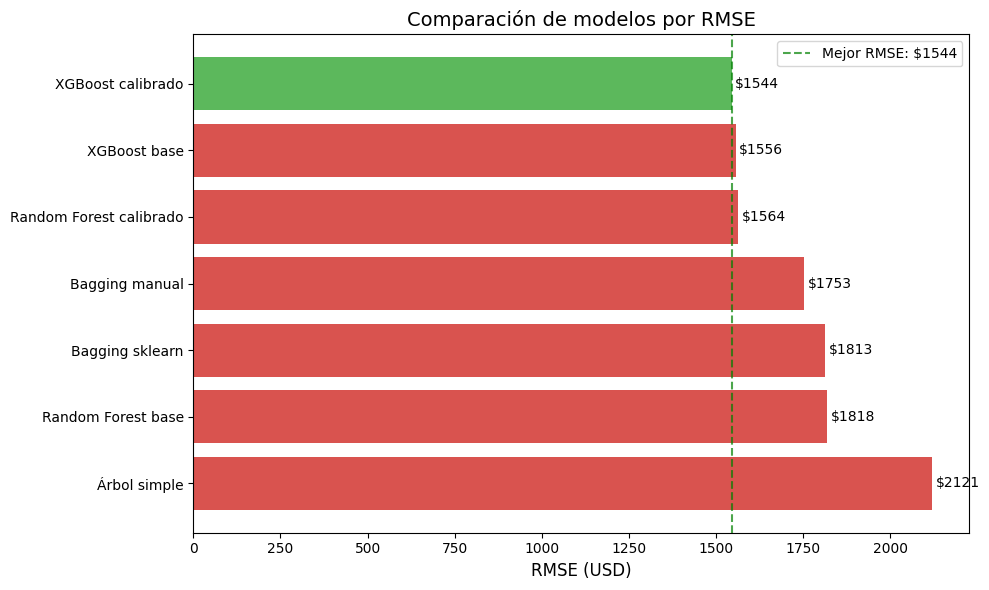

In [30]:
# Gráfica 1: Comparación de modelos por RMSE

import matplotlib.pyplot as plt
import numpy as np

modelos = [
    'Árbol simple',
    'Bagging manual',
    'Bagging sklearn',
    'Random Forest base',
    'Random Forest calibrado',
    'XGBoost base',
    'XGBoost calibrado'
]

rmse_valores = [rmse, rmse_bag, rmse_bagging, rmse_rf, rmse_rf5, rmse_xgb, rmse_xgb5]
mae_valores = [mae, mae_bag, mae_bagging, mae_rf, mae_rf5, mae_xgb, mae_xgb5]

# Ordenar de mayor a menor RMSE 
orden = np.argsort(rmse_valores)[::-1]
modelos_ord = [modelos[i] for i in orden]
rmse_ord = [rmse_valores[i] for i in orden]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(modelos_ord, rmse_ord, color=['#d9534f' if 'XGBoost calibrado' not in m 
                                              else '#5cb85c' for m in modelos_ord])

ax.axvline(x=min(rmse_valores), color='green', linestyle='--', alpha=0.7, label=f'Mejor RMSE: ${min(rmse_valores):.0f}')
ax.set_xlabel('RMSE (USD)', fontsize=12)
ax.set_title('Comparación de modelos por RMSE', fontsize=14)
ax.legend()

for bar, val in zip(bars, rmse_ord):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

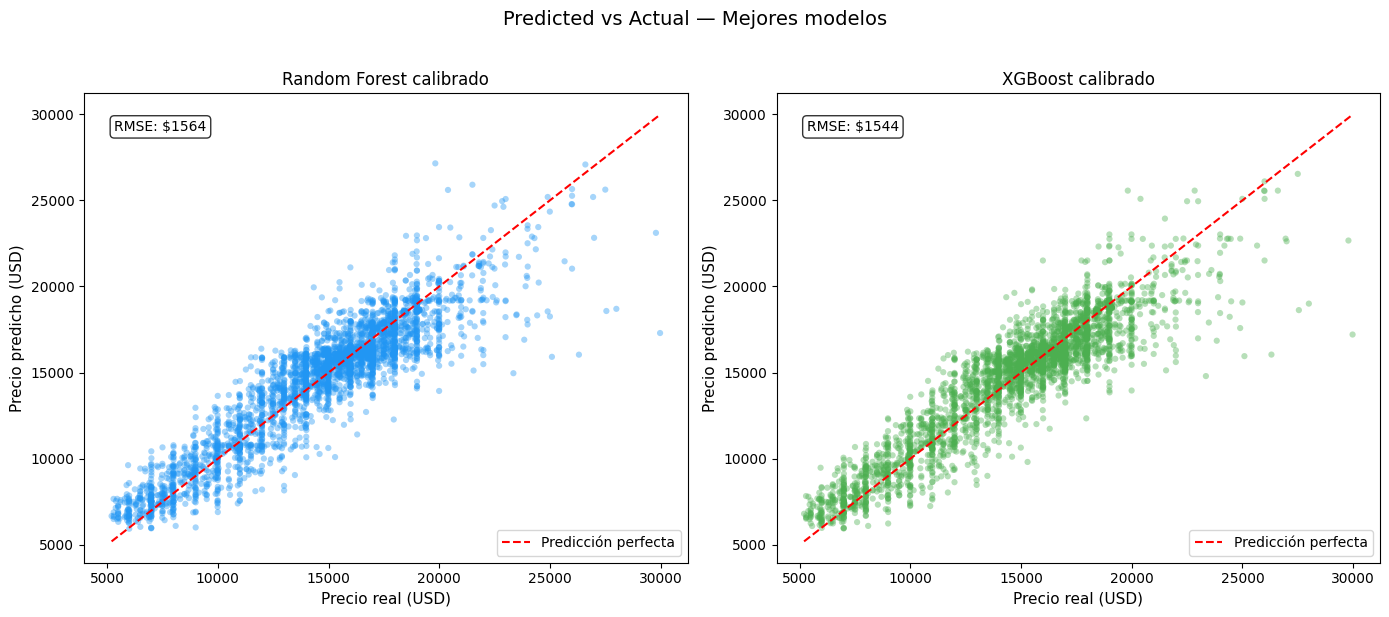

In [ ]:
# Gráfica 2: Predicted vs Actual para RF calibrado y XGBoost calibrado

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos_pred = [
    (y_pred_rf5, 'Random Forest calibrado', '#2196F3'),
    (y_pred_xgb5, 'XGBoost calibrado', '#4CAF50')
]

for ax, (y_pred, nombre, color) in zip(axes, modelos_pred):
    ax.scatter(y_test, y_pred, alpha=0.4, color=color, edgecolors='none', s=20)
    
    # Diagonal
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    ax.plot([minval, maxval], [minval, maxval], 'r--', linewidth=1.5, label='Predicción perfecta')
    
    ax.set_xlabel('Precio real (USD)', fontsize=11)
    ax.set_ylabel('Precio predicho (USD)', fontsize=11)
    ax.set_title(nombre, fontsize=12)
    ax.legend()
    
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.text(0.05, 0.92, f'RMSE: ${rmse_val:.0f}', transform=ax.transAxes,
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Predicted vs Actual - Mejores modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Conclusiones Punto 8:**

El mejor modelo fue XGBoost calibrado (RMSE: $1,544 y MAE: $1,135), seguido de cerca por Random Forest calibrado (RMSE: $1,564 y MAE: $1,146). Ambos superaron ampliamente al árbol simple y a los modelos de Bagging sin calibrar.

**Ventajas de XGBoost (mejor modelo):**
XGBoost construye árboles secuencialmente, donde cada árbol corrige los residuos del anterior. Esto permite reducir tanto el sesgo como la varianza del modelo, logrando mayor precisión con menos árboles. Su sistema de regularización mediante `learning_rate`, `gamma` y `colsample_bytree` ofrece un control fino sobre el sobreajuste.

**Desventajas de Random Forest (menor desempeño entre los calibrados):**
Random Forest construye árboles en paralelo sobre muestras bootstrap, lo que reduce principalmente la varianza pero no ataca el sesgo directamente. Cada árbol es independiente y no aprende de los errores de los anteriores, lo que limita su precisión máxima respecto a métodos secuenciales como XGBoost. Sin embargo, su naturaleza paralela lo hace computacionalmente más eficiente y más fácil de escalar.